In [1]:
%pip install xgboost
import pickle, time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

Note: you may need to restart the kernel to use updated packages.


In [2]:
X_train = sp.load_npz('X_train_tfidf.npz')
X_val   = sp.load_npz('X_val_tfidf.npz')
X_test  = sp.load_npz('X_test_tfidf.npz')

y_train = pd.read_csv('y_train.csv').values.ravel()
y_val   = pd.read_csv('y_val.csv').values.ravel()
y_test  = pd.read_csv('y_test.csv').values.ravel()

LABELS = ['negative', 'neutral', 'positive']

print(f'Train: {X_train.shape}')
print(f'Validation: {X_val.shape}')
print(f'Test: {X_test.shape}')

Train: (10248, 10000)
Validation: (2196, 10000)
Test: (2196, 10000)


In [3]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42),
    'Linear SVM'         : LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=200, max_depth=6, eval_metric='mlogloss', random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    t = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    results[name] = {
        'model'      : model,
        'y_pred'     : y_pred,
        'accuracy'   : accuracy_score(y_val, y_pred),
        'f1_weighted': f1_score(y_val, y_pred, average='weighted'),
        'f1_macro'   : f1_score(y_val, y_pred, average='macro'),
        'time'       : round(time.time() - t, 1)
    }
    print(f'{name:<22} Acc: {results[name]["accuracy"]:.4f} | F1w: {results[name]["f1_weighted"]:.4f} | {results[name]["time"]}s')

Logistic Regression    Acc: 0.7532 | F1w: 0.7616 | 0.5s
Linear SVM             Acc: 0.7587 | F1w: 0.7614 | 0.1s
Naive Bayes            Acc: 0.7450 | F1w: 0.7200 | 0.0s


c:\Users\dell\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Random Forest          Acc: 0.7632 | F1w: 0.7560 | 4.9s
XGBoost                Acc: 0.7664 | F1w: 0.7622 | 11.7s


In [4]:
summary = pd.DataFrame([
    {'Model': n, 'Accuracy': r['accuracy'], 'F1 Weighted': r['f1_weighted'],
     'F1 Macro': r['f1_macro'], 'Time(s)': r['time']}
    for n, r in results.items()
]).sort_values('F1 Weighted', ascending=False).reset_index(drop=True)

summary.index += 1
print(summary.round(4).to_string())

                 Model  Accuracy  F1 Weighted  F1 Macro  Time(s)
1              XGBoost    0.7664       0.7622    0.6944     11.7
2  Logistic Regression    0.7532       0.7616    0.7070      0.5
3           Linear SVM    0.7587       0.7614    0.6977      0.1
4        Random Forest    0.7632       0.7560    0.6854      4.9
5          Naive Bayes    0.7450       0.7200    0.6355      0.0


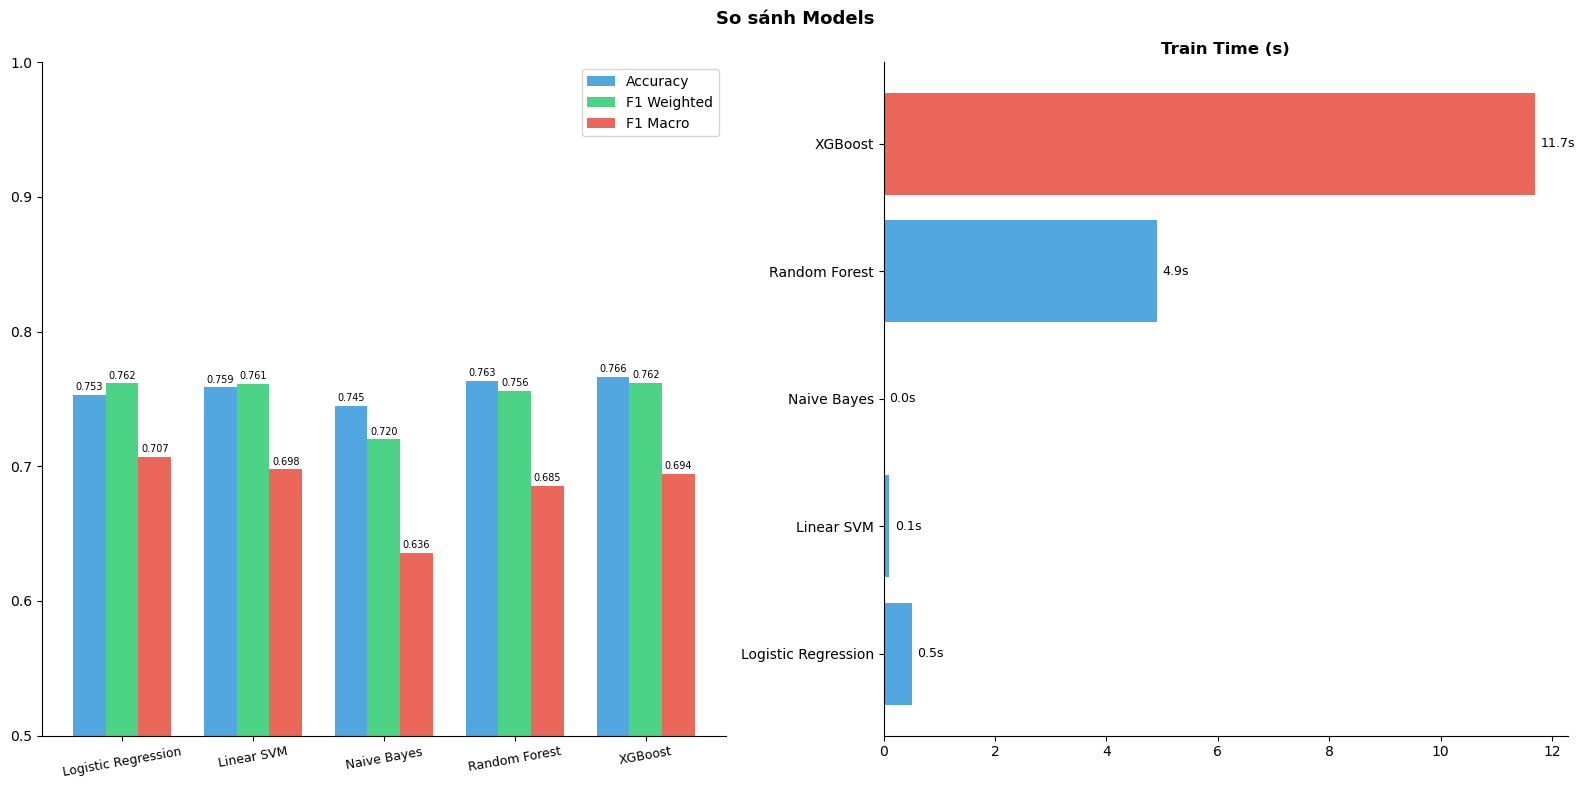

In [5]:
names  = list(results.keys())
x      = np.arange(len(names))
width  = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('So sánh Models', fontsize=13, fontweight='bold')

# F1 scores
for i, (metric, color, label) in enumerate([
    ('accuracy',    '#3498db', 'Accuracy'),
    ('f1_weighted', '#2ecc71', 'F1 Weighted'),
    ('f1_macro',    '#e74c3c', 'F1 Macro')
]):
    axes[0].bar(x + (i-1)*width, [results[n][metric] for n in names],
                width, label=label, color=color, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=9, rotation=10)
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)
for bars in axes[0].containers:
    axes[0].bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

# Train time
times = [results[n]['time'] for n in names]
axes[1].barh(names, times,
             color=['#e74c3c' if t == max(times) else '#3498db' for t in times], alpha=0.85)
axes[1].set_title('Train Time (s)', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
for i, t in enumerate(times):
    axes[1].text(t + 0.1, i, f'{t}s', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

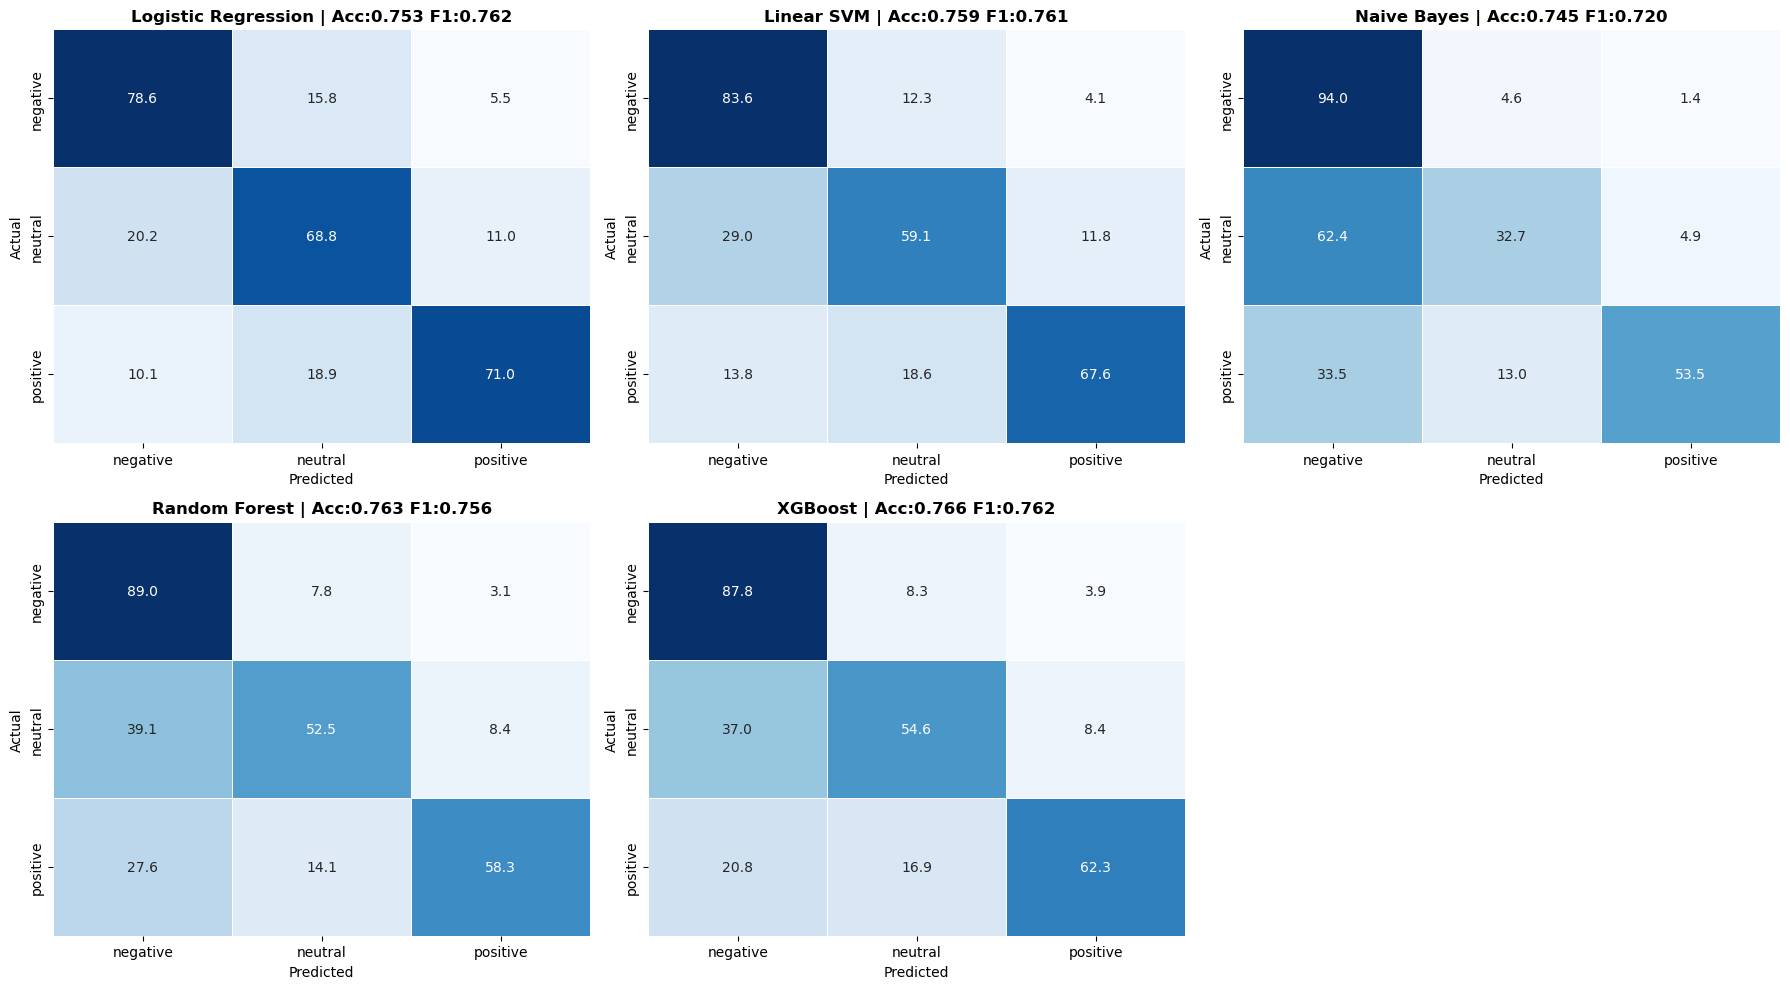

In [6]:
ncols = 3
nrows = -(-len(results) // ncols)   # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_val, r['y_pred']).astype(float)
    cm = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS,
                ax=axes[i], cbar=False, linewidths=0.5)
    axes[i].set_title(f'{name} | Acc:{r["accuracy"]:.3f} F1:{r["f1_weighted"]:.3f}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
best_name  = summary.iloc[0]['Model']
best_model = results[best_name]['model']

y_pred_val = results[best_name]['y_pred']

print(f' Best Model : {best_name}')
print(f'   Accuracy   : {results[best_name]["accuracy"]:.4f}')
print(f'   F1 Weighted: {results[best_name]["f1_weighted"]:.4f}')
print(f'   F1 Macro   : {results[best_name]["f1_macro"]:.4f}')

print("Classification Report on Validation Set:")
print(classification_report(y_val, y_pred_val, target_names=LABELS))

# Lưu best model
pickle.dump(best_model, open('best_model.pkl', 'wb'))
with open('best_model_name.txt', 'w') as f:
    f.write(best_name)

 Best Model : XGBoost
   Accuracy   : 0.7664
   F1 Weighted: 0.7622
   F1 Macro   : 0.6944
Classification Report on Validation Set:
              precision    recall  f1-score   support

    negative       0.83      0.88      0.85      1376
     neutral       0.59      0.55      0.57       465
    positive       0.70      0.62      0.66       355

    accuracy                           0.77      2196
   macro avg       0.71      0.68      0.69      2196
weighted avg       0.76      0.77      0.76      2196

